# Week 7 — Classification: Logistic Regression, Naive Bayes, KNN
- **Week 4:** Loaded 2452 RAVDESS files. Neutral has fewer samples (no strong intensity variant). Angry vs calm visually distinct in waveforms.
- **Week 5:** Extracted 112 features. Saved train (1956, 112) and test (496, 112).
- **Week 6:** Regression analysis. Best R² was only 0.308 (Ridge on arousal). Binary intensity R² = 0.22. **Conclusion: the emotion-feature relationship is substantially non-linear. Linear models cannot explain it well.**

## This week
We switch from regression to classification. Instead of predicting a continuous score, we predict one of 8 discrete emotion labels.

Three classifiers with fundamentally different approaches:
1. **Logistic Regression** — linear decision boundary, our baseline
2. **Gaussian Naive Bayes** — probabilistic, no gradient descent, assumes feature independence
3. **K-Nearest Neighbors** — non-parametric, no assumptions, uses distance to neighbors
.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('..')

from minilearn.classifiers.logistic_regression  import LogisticRegression
from minilearn.classifiers.naive_bayes import GaussianNaiveBayes
from minilearn.classifiers.knn                  import KNearestNeighbors
from minilearn.metrics.classification_metrics import (
    accuracy, classification_report,
    plot_confusion_matrix, f1_score,
    precision, recall
)

os.makedirs('../outputs', exist_ok=True)

# load directly from week 5 saved outputs — no re-extraction
X_train_sc = np.load('../outputs/X_train_sc.npy')
X_test_sc  = np.load('../outputs/X_test_sc.npy')
y_train    = np.load('../outputs/y_train.npy')
y_test     = np.load('../outputs/y_test.npy')
feat_cols  = pd.read_csv('../outputs/feature_names.csv').iloc[:, 0].tolist()

EMOTION_NAMES = {
    1:'neutral', 2:'calm',    3:'happy',    4:'sad',
    5:'angry',   6:'fearful', 7:'disgust',  8:'surprised'
}
LABELS = [EMOTION_NAMES[i] for i in sorted(EMOTION_NAMES.keys())]

print(f'Train : {X_train_sc.shape}')
print(f'Test  : {X_test_sc.shape}')
print(f'Classes: {np.unique(y_train)}')

Train : (1956, 112)
Test  : (496, 112)
Classes: [1 2 3 4 5 6 7 8]


## 1. Logistic Regression

Learns a weight per feature per class. Uses softmax to convert raw scores to probabilities. Trained with gradient descent minimising cross-entropy loss.

This is our **linear baseline** — if Week 6 regression struggled (R²=0.308), we expect LR to also struggle with emotions at similar arousal levels (calm vs neutral, happy vs surprised).

In [31]:
lr = LogisticRegression(
    lr=0.1, n_iter=1000,
    reg_lambda=0.01,
    random_state=42,
    verbose=False
)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print(f'Accuracy : {accuracy(y_test, y_pred_lr):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_lr, average="macro"):.4f}')
print(f'Macro P  : {precision(y_test, y_pred_lr, average="macro"):.4f}')
print(f'Macro R  : {recall(y_test, y_pred_lr, average="macro"):.4f}')
print()
report_lr = classification_report(y_test, y_pred_lr, labels=LABELS)

Accuracy : 0.6149
Macro F1 : 0.6236
Macro P  : 0.6235
Macro R  : 0.6239

       Class   Precision    Recall        F1   Support
------------------------------------------------------
     neutral      0.6579    0.6579    0.6579        38
        calm      0.6623    0.6711    0.6667        76
       happy      0.5974    0.6053    0.6013        76
         sad      0.4750    0.5000    0.4872        76
       angry      0.7763    0.7763    0.7763        76
     fearful      0.4857    0.4474    0.4658        76
     disgust      0.7179    0.7179    0.7179        39
   surprised      0.6154    0.6154    0.6154        39
------------------------------------------------------
   macro avg      0.6235    0.6239    0.6236       496
weighted avg      0.6144    0.6149    0.6145       496


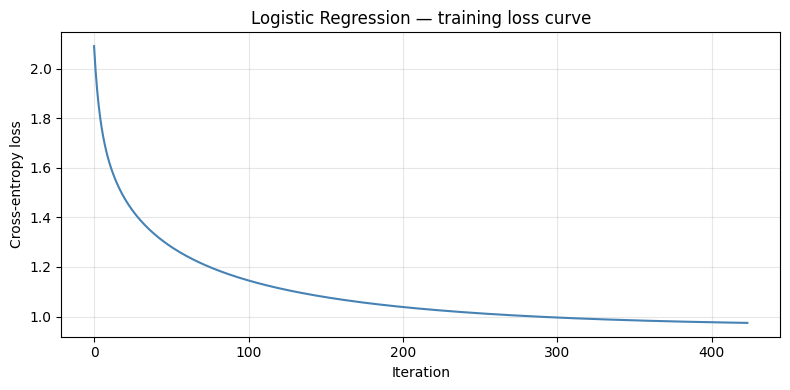

In [32]:
# loss curve — confirms gradient descent converged properly
# if still dropping at iter 1000 → increase n_iter
# if noisy/jumping → decrease lr
plt.figure(figsize=(8, 4))
plt.plot(lr.loss_curve_, color='steelblue', linewidth=1.5)
plt.xlabel('Iteration')
plt.ylabel('Cross-entropy loss')
plt.title('Logistic Regression — training loss curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/lr_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

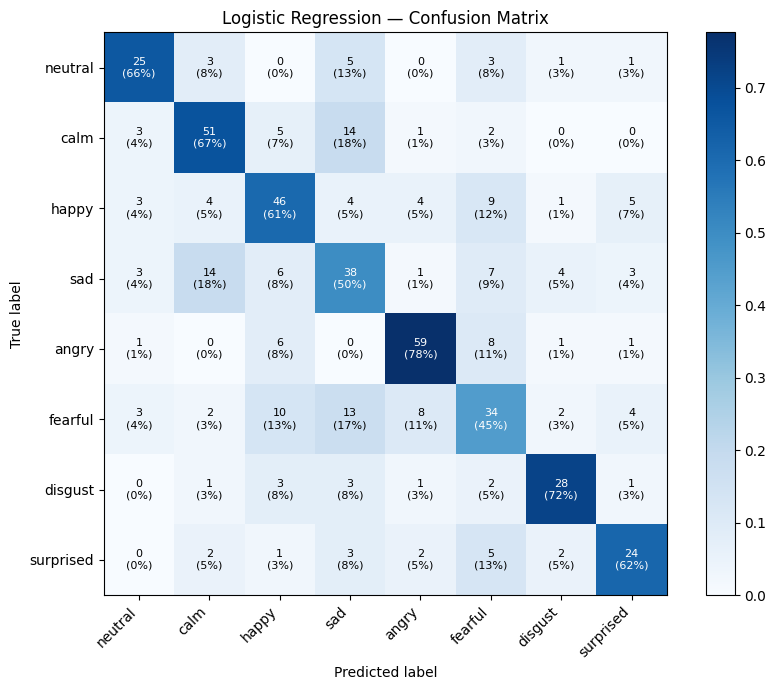

In [33]:
# confusion matrix
# diagonal = correct predictions
# off-diagonal = misclassifications — look for calm/neutral confusion
fig, ax = plt.subplots(figsize=(9, 7))
plot_confusion_matrix(
    y_test, y_pred_lr, labels=LABELS,
    title='Logistic Regression — Confusion Matrix', ax=ax
)
plt.tight_layout()
plt.savefig('../outputs/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Logistic Regression — Hyperparameter Tuning

Two parameters to tune:
- **lr (learning rate):** how big each gradient step is
- **reg_lambda:** L2 regularisation strength — higher = simpler model, less overfit

In [34]:
print(f'{'lr':>8}  {'reg':>8}  {'acc':>8}  {'f1':>8}')
print('-' * 38)

lr_tune = []
for learning_rate in [0.001, 0.01, 0.1]:
    for reg in [0.001, 0.01, 0.1, 1.0]:
        m   = LogisticRegression(lr=learning_rate, reg_lambda=reg,
                                 n_iter=500, random_state=42)
        m.fit(X_train_sc, y_train)
        y_p = m.predict(X_test_sc)
        acc = accuracy(y_test, y_p)
        f1  = f1_score(y_test, y_p, average='macro')
        lr_tune.append({'lr':learning_rate, 'reg':reg, 'acc':acc, 'f1':f1})
        print(f'{learning_rate:>8}  {reg:>8}  {acc:>8.4f}  {f1:>8.4f}')

lr_tune_df = pd.DataFrame(lr_tune)
best_lr    = lr_tune_df.loc[lr_tune_df['f1'].idxmax()]
print(f'\nBest: lr={best_lr["lr"]}  reg={best_lr["reg"]}  f1={best_lr["f1"]:.4f}')

      lr       reg       acc        f1
--------------------------------------
   0.001     0.001    0.3508    0.2788
   0.001      0.01    0.3508    0.2788
   0.001       0.1    0.3508    0.2788
   0.001       1.0    0.3508    0.2788
    0.01     0.001    0.5040    0.4934
    0.01      0.01    0.5040    0.4934
    0.01       0.1    0.5040    0.4934
    0.01       1.0    0.3710    0.3002
     0.1     0.001    0.6190    0.6272
     0.1      0.01    0.6149    0.6236
     0.1       0.1    0.5343    0.5321
     0.1       1.0    0.6210    0.6294

Best: lr=0.1  reg=1.0  f1=0.6294


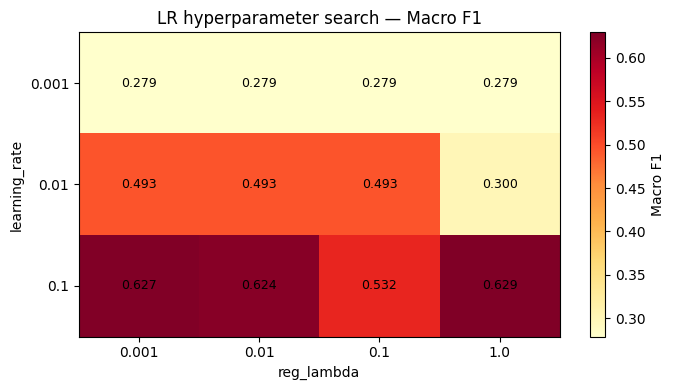

In [35]:
# heatmap to visualise the tuning grid
pivot = lr_tune_df.pivot(index='lr', columns='reg', values='f1')

plt.figure(figsize=(7, 4))
im = plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, label='Macro F1')
plt.xticks(range(len(pivot.columns)), [str(c) for c in pivot.columns])
plt.yticks(range(len(pivot.index)),   [str(i) for i in pivot.index])
plt.xlabel('reg_lambda')
plt.ylabel('learning_rate')
plt.title('LR hyperparameter search — Macro F1')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f'{pivot.values[i,j]:.3f}',
                 ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/lr_hyperparam_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Gaussian Naive Bayes

No gradient descent — training just computes per-class mean and variance for each feature. Predicts using Bayes theorem. Assumes all features are independent of each other (the naive assumption).

This assumption is almost certainly false for MFCCs (adjacent coefficients are correlated). But the model may still do well on emotions with very distinctive per-feature distributions.

In [36]:
gnb = GaussianNaiveBayes(var_smoothing=1e-9)
gnb.fit(X_train_sc, y_train)
y_pred_gnb = gnb.predict(X_test_sc)

print(f'Accuracy : {accuracy(y_test, y_pred_gnb):.4f}')
print(f'Macro F1 : {f1_score(y_test, y_pred_gnb, average="macro"):.4f}')
print(f'Macro P  : {precision(y_test, y_pred_gnb, average="macro"):.4f}')
print(f'Macro R  : {recall(y_test, y_pred_gnb, average="macro"):.4f}')
print()
report_gnb = classification_report(y_test, y_pred_gnb, labels=LABELS)

Accuracy : 0.3468
Macro F1 : 0.3343
Macro P  : 0.3672
Macro R  : 0.3478

       Class   Precision    Recall        F1   Support
------------------------------------------------------
     neutral      0.2973    0.2895    0.2933        38
        calm      0.6111    0.4342    0.5077        76
       happy      0.2793    0.4079    0.3316        76
         sad      0.5385    0.1842    0.2745        76
       angry      0.5000    0.5132    0.5065        76
     fearful      0.2979    0.1842    0.2276        76
     disgust      0.1897    0.2821    0.2268        39
   surprised      0.2235    0.4872    0.3065        39
------------------------------------------------------
   macro avg      0.3672    0.3478    0.3343       496
weighted avg      0.3965    0.3468    0.3475       496


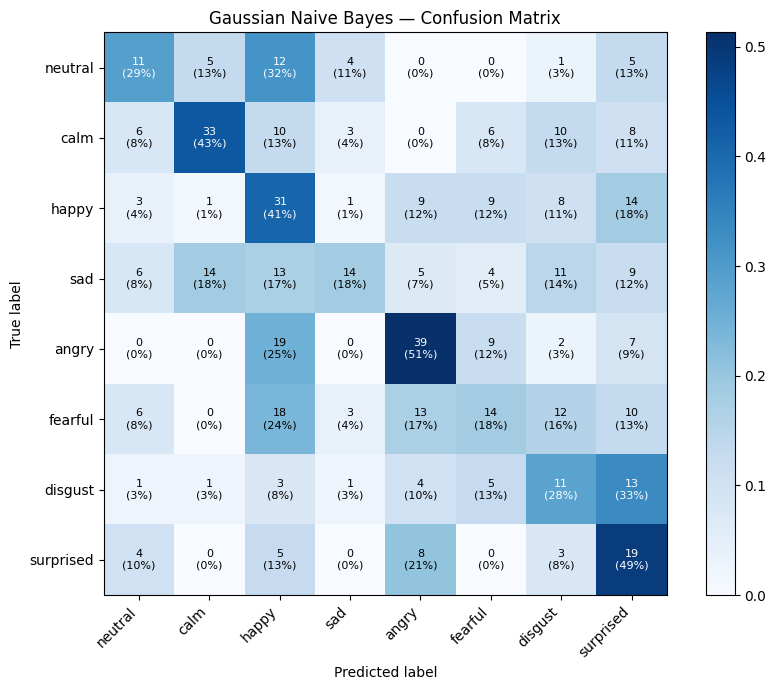

In [37]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_confusion_matrix(
    y_test, y_pred_gnb, labels=LABELS,
    title='Gaussian Naive Bayes — Confusion Matrix', ax=ax
)
plt.tight_layout()
plt.savefig('../outputs/gnb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

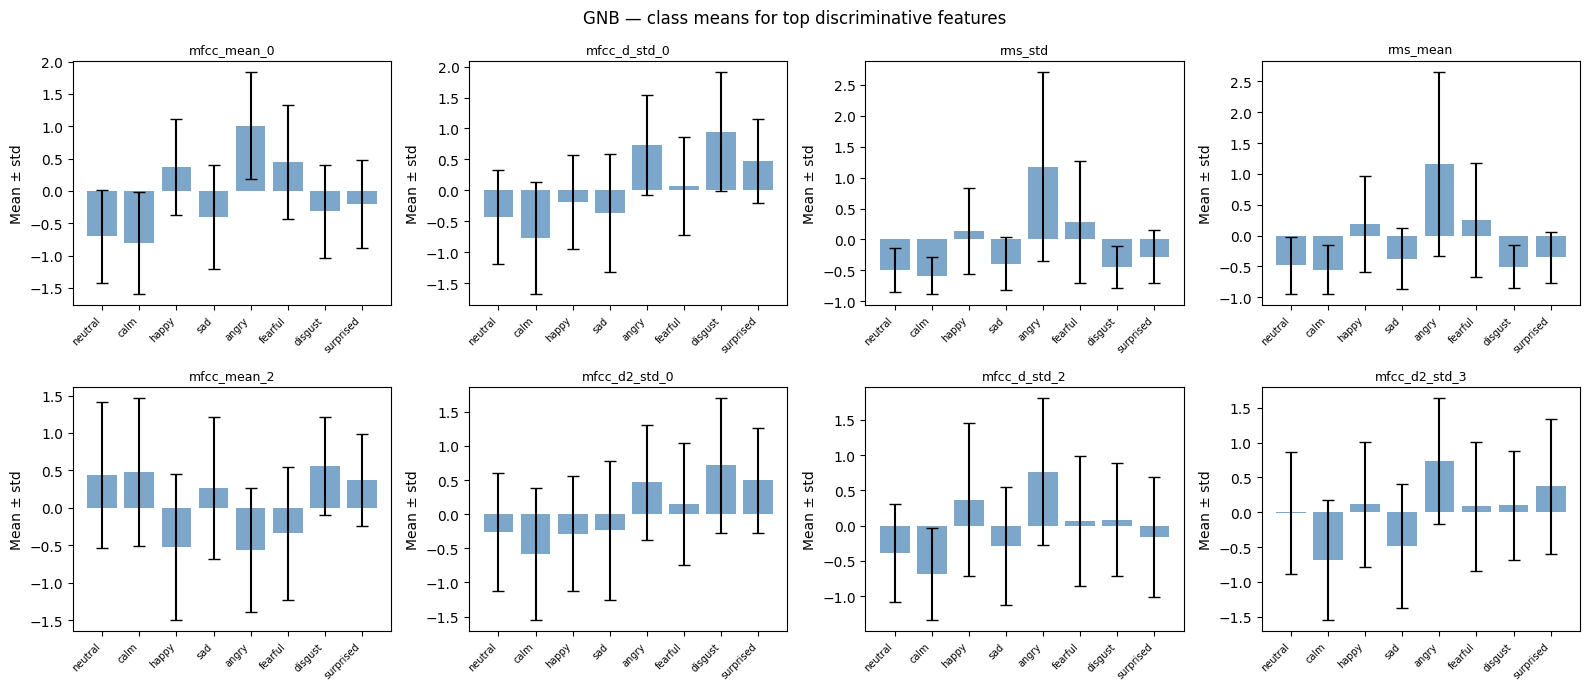

In [38]:
# what GNB actually learned — class means for most discriminative features
# bars show mean ± std for each emotion
# well-separated bars = feature is useful for classification
top_feats      = gnb.most_discriminative_features(feat_cols, top_n=8)
feat_names_top = [f[0] for f in top_feats]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes      = axes.flatten()

for ax, feat in zip(axes, feat_names_top):
    idx   = feat_cols.index(feat)
    means = gnb.means_[:, idx]
    stds  = np.sqrt(gnb.vars_[:, idx])
    ax.bar(range(len(gnb.classes_)), means, yerr=stds,
           capsize=4, color='steelblue', alpha=0.7)
    ax.set_xticks(range(len(gnb.classes_)))
    ax.set_xticklabels(LABELS, rotation=45, ha='right', fontsize=7)
    ax.set_title(feat, fontsize=9)
    ax.set_ylabel('Mean ± std')

plt.suptitle('GNB — class means for top discriminative features', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/gnb_class_means.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** GNB learned meaningful per-emotion feature distributions. Features where bars differ significantly across emotions are the most useful. Features where all bars look similar contribute little to classification — this connects back to our Week 5 correlation analysis.

## 4. K-Nearest Neighbors

No training at all — memorises the training set. For each test sample, finds the k most similar training samples by distance and takes a majority vote.

Key decisions:
- **k:** how many neighbors to consider
- **metric:** how to measure similarity (euclidean, manhattan, cosine)
- **weights:** uniform vote or weight closer neighbors more

In [39]:
# tune k and metric — try all combinations
print(f'{'k':>5}  {'metric':>12}  {'acc':>8}  {'f1':>8}')
print('-' * 38)

knn_results = []
for k in [3, 5, 7, 11, 15]:
    for metric in ['euclidean', 'manhattan', 'cosine']:
        knn = KNearestNeighbors(k=k, metric=metric)
        knn.fit(X_train_sc, y_train)
        y_p = knn.predict(X_test_sc)
        acc = accuracy(y_test, y_p)
        f1  = f1_score(y_test, y_p, average='macro')
        knn_results.append({'k':k, 'metric':metric, 'acc':acc, 'f1':f1})
        print(f'{k:>5}  {metric:>12}  {acc:>8.4f}  {f1:>8.4f}')

knn_df   = pd.DataFrame(knn_results)
best_knn = knn_df.loc[knn_df['f1'].idxmax()]
print(f'\nBest: k={int(best_knn["k"])}  metric={best_knn["metric"]}  f1={best_knn["f1"]:.4f}')

    k        metric       acc        f1
--------------------------------------
    3     euclidean    0.6028    0.5852
    3     manhattan    0.6190    0.6009
    3        cosine    0.5726    0.5602
    5     euclidean    0.5786    0.5529
    5     manhattan    0.6008    0.5860
    5        cosine    0.5565    0.5421
    7     euclidean    0.5746    0.5579
    7     manhattan    0.5746    0.5610
    7        cosine    0.5504    0.5296
   11     euclidean    0.5383    0.5125
   11     manhattan    0.5645    0.5468
   11        cosine    0.5161    0.5026
   15     euclidean    0.5101    0.4881
   15     manhattan    0.5464    0.5321
   15        cosine    0.4919    0.4645

Best: k=3  metric=manhattan  f1=0.6009


In [40]:
# train best KNN with distance weighting
# weights='distance' means closer neighbors get more vote weight
knn_best = KNearestNeighbors(
    k=int(best_knn['k']),
    metric=best_knn['metric'],
    weights='distance'
)
knn_best.fit(X_train_sc, y_train)
y_pred_knn = knn_best.predict(X_test_sc)

print(f'Best KNN Accuracy : {accuracy(y_test, y_pred_knn):.4f}')
print(f'Best KNN Macro F1 : {f1_score(y_test, y_pred_knn, average="macro"):.4f}')
print()
report_knn = classification_report(y_test, y_pred_knn, labels=LABELS)

Best KNN Accuracy : 0.6190
Best KNN Macro F1 : 0.6009

       Class   Precision    Recall        F1   Support
------------------------------------------------------
     neutral      0.3947    0.3947    0.3947        38
        calm      0.6842    0.6842    0.6842        76
       happy      0.6067    0.7105    0.6545        76
         sad      0.5526    0.5526    0.5526        76
       angry      0.6988    0.7632    0.7296        76
     fearful      0.6508    0.5395    0.5899        76
     disgust      0.5938    0.4872    0.5352        39
   surprised      0.6667    0.6667    0.6667        39
------------------------------------------------------
   macro avg      0.6060    0.5998    0.6009       496
weighted avg      0.6186    0.6190    0.6167       496


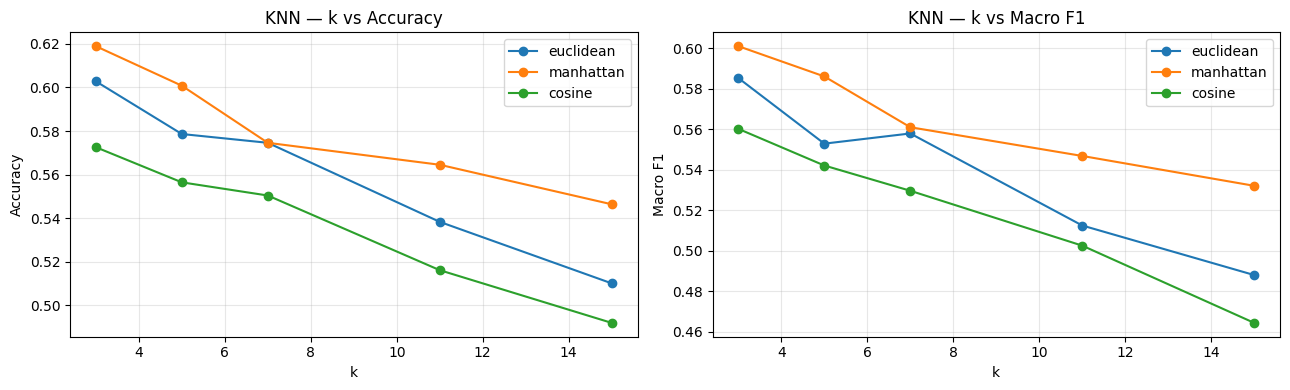

In [41]:
# k vs accuracy and F1 for each distance metric
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for metric in ['euclidean', 'manhattan', 'cosine']:
    sub = knn_df[knn_df['metric'] == metric].sort_values('k')
    axes[0].plot(sub['k'], sub['acc'], marker='o', label=metric)
    axes[1].plot(sub['k'], sub['f1'],  marker='o', label=metric)

for ax, ylabel in zip(axes, ['Accuracy', 'Macro F1']):
    ax.set_xlabel('k')
    ax.set_ylabel(ylabel)
    ax.set_title(f'KNN — k vs {ylabel}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/knn_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

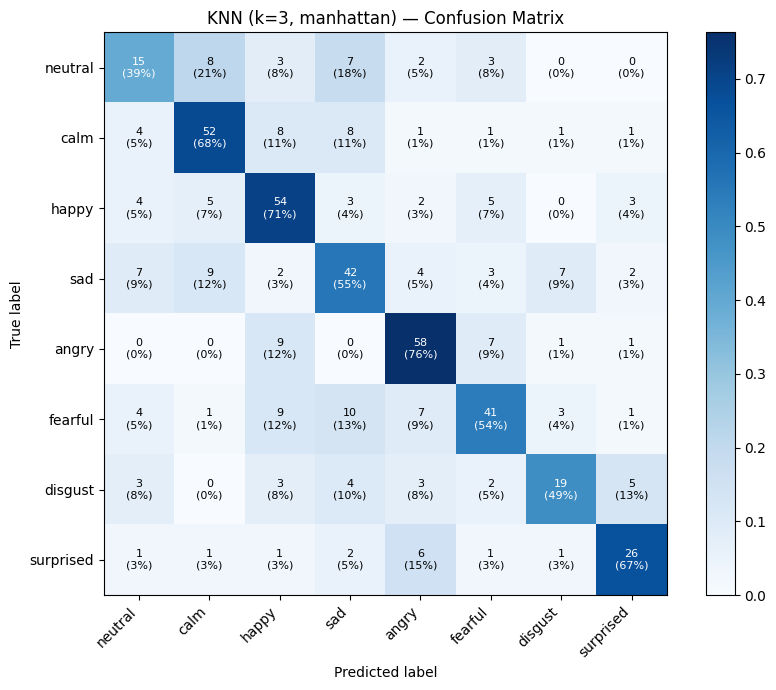

In [42]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_confusion_matrix(
    y_test, y_pred_knn, labels=LABELS,
    title=f'KNN (k={int(best_knn["k"])}, {best_knn["metric"]}) — Confusion Matrix',
    ax=ax
)
plt.tight_layout()
plt.savefig('../outputs/knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Head-to-Head Comparison

In [43]:
models = {
    'Logistic Regression'                                      : y_pred_lr,
    'Gaussian Naive Bayes'                                     : y_pred_gnb,
    f'KNN k={int(best_knn["k"])} {best_knn["metric"]}'       : y_pred_knn,
}

print(f'{'Model':35s}  {'Accuracy':>10}  {'Macro F1':>10}  {'Macro P':>10}  {'Macro R':>10}')
print('-' * 80)

summary = []
for name, y_pred in models.items():
    acc  = accuracy(y_test,  y_pred)
    f1   = f1_score(y_test,  y_pred, average='macro')
    prec = precision(y_test, y_pred, average='macro')
    rec  = recall(y_test,    y_pred, average='macro')
    summary.append({'Model':name, 'Accuracy':acc,
                    'Macro F1':f1, 'Macro P':prec, 'Macro R':rec})
    print(f'{name:35s}  {acc:>10.4f}  {f1:>10.4f}  {prec:>10.4f}  {rec:>10.4f}')

Model                                  Accuracy    Macro F1     Macro P     Macro R
--------------------------------------------------------------------------------
Logistic Regression                      0.6149      0.6236      0.6235      0.6239
Gaussian Naive Bayes                     0.3468      0.3343      0.3672      0.3478
KNN k=3 manhattan                        0.6190      0.6009      0.6060      0.5998


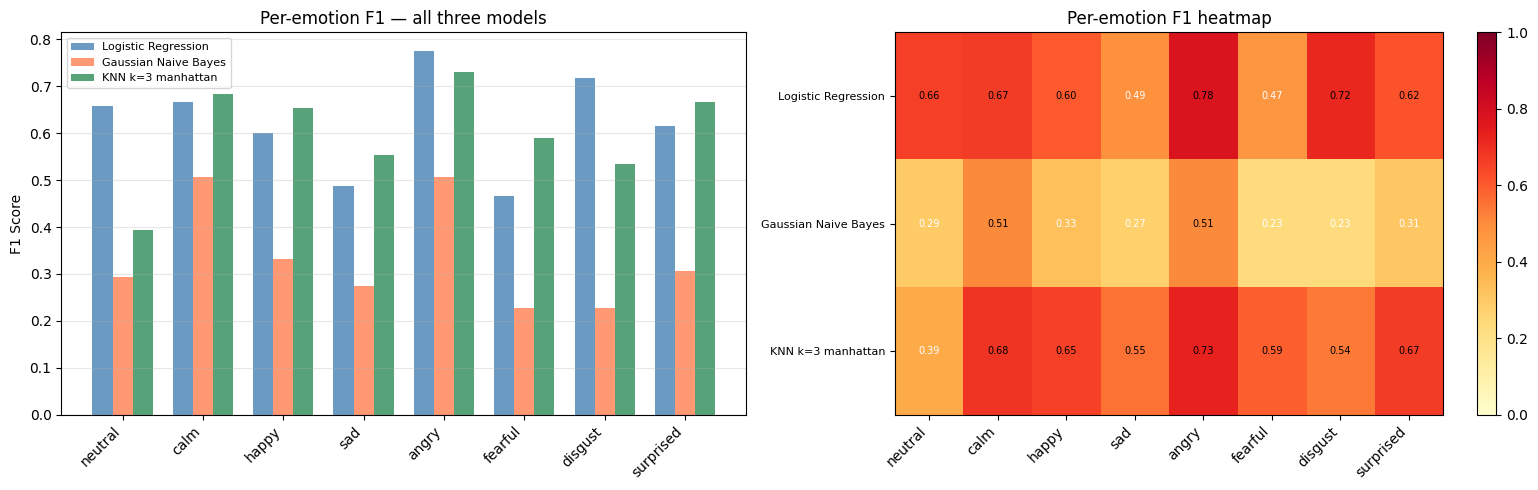

In [44]:
# per-emotion F1 grouped bar chart + heatmap
per_class_f1 = {}
for name, y_pred in models.items():
    f1_vals, _ = f1_score(y_test, y_pred, average='per_class')
    per_class_f1[name] = f1_vals

x      = np.arange(len(LABELS))
width  = 0.25
colors = ['steelblue', 'coral', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, (name, vals) in enumerate(per_class_f1.items()):
    axes[0].bar(x + i*width, vals, width,
                label=name, color=colors[i], alpha=0.8)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(LABELS, rotation=45, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Per-emotion F1 — all three models')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

per_f1_df = pd.DataFrame(per_class_f1, index=LABELS)
im = axes[1].imshow(per_f1_df.T.values, cmap='YlOrRd',
                    aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks(range(len(LABELS)))
axes[1].set_xticklabels(LABELS, rotation=45, ha='right')
axes[1].set_yticks(range(len(models)))
axes[1].set_yticklabels(list(models.keys()), fontsize=8)
axes[1].set_title('Per-emotion F1 heatmap')
for i in range(len(models)):
    for j in range(len(LABELS)):
        val = per_f1_df.T.values[i, j]
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=7,
                     color='black' if val > 0.5 else 'white')

plt.tight_layout()
plt.savefig('../outputs/week7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

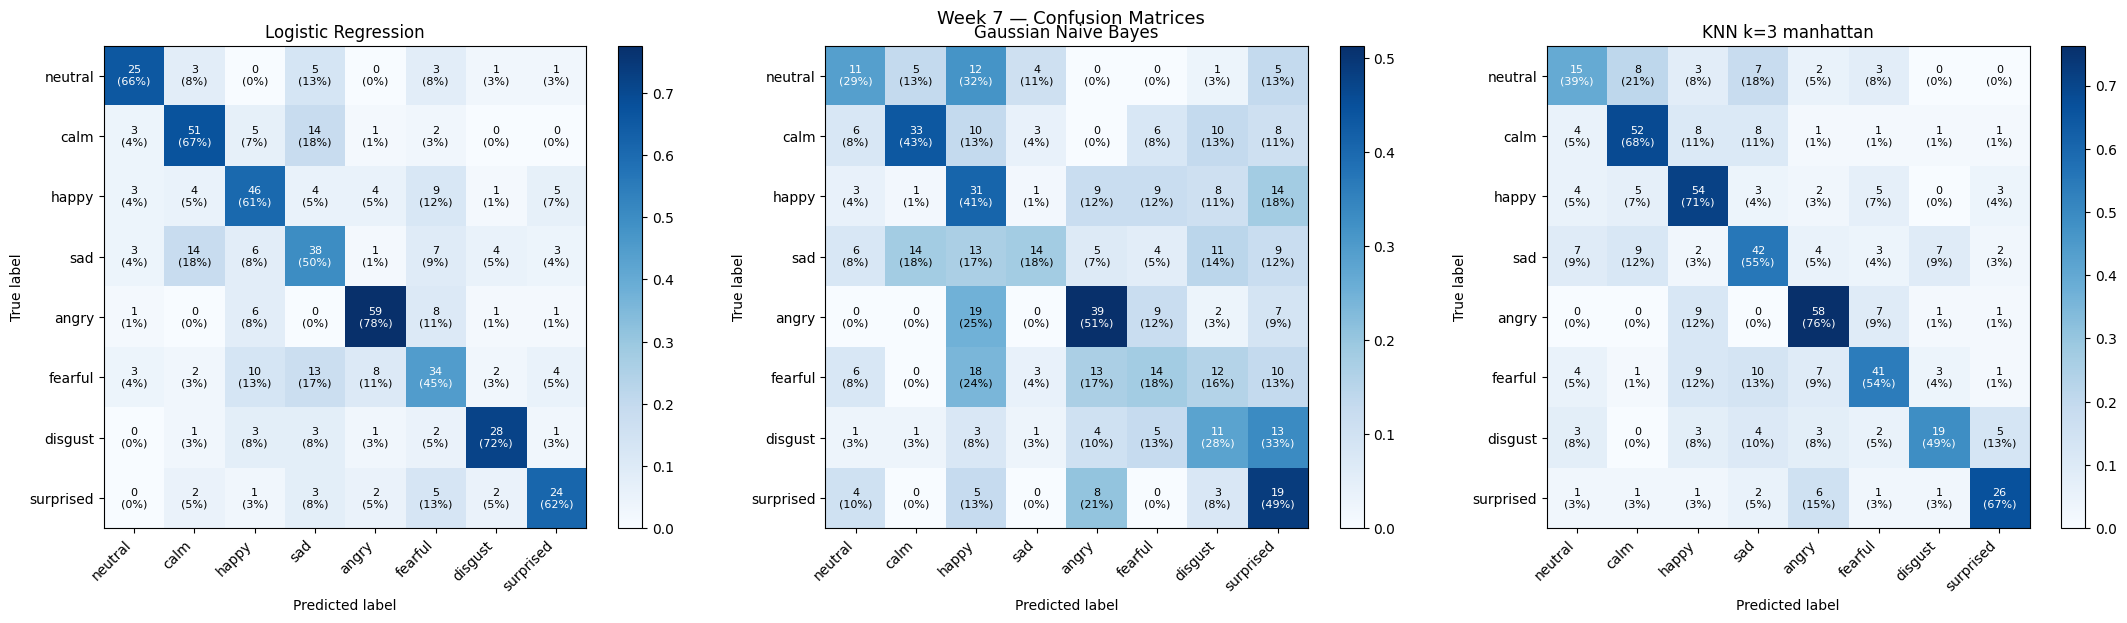

In [45]:
# three confusion matrices side by side for direct comparison
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (name, y_pred) in zip(axes, models.items()):
    plot_confusion_matrix(y_test, y_pred, labels=LABELS, title=name, ax=ax)
plt.suptitle('Week 7 — Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/week7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC / AUC — From Scratch

In [46]:
def compute_roc_auc(y_true, y_proba, classes):
    """
    One-vs-Rest ROC AUC — from scratch using numpy only.
    For each class: treat as positive, all others as negative.
    AUC computed via trapezoidal rule.
    """
    aucs = []
    for i, cls in enumerate(classes):
        y_bin  = (y_true == cls).astype(int)
        scores = y_proba[:, i]
        order  = np.argsort(scores)[::-1]
        y_s    = y_bin[order]
        tp     = np.cumsum(y_s)
        fp     = np.cumsum(1 - y_s)
        tpr    = tp / (tp.max() + 1e-10)
        fpr    = fp / (fp.max() + 1e-10)
        aucs.append(abs(np.trapezoid(tpr, fpr)))
    return np.array(aucs), np.mean(aucs)

print(f'{'Model':35s}  {'Macro AUC':>10}')
print('-' * 50)

for name, model in zip(models.keys(), [lr, gnb, knn_best]):
    proba        = model.predict_proba(X_test_sc)
    _, macro_auc = compute_roc_auc(y_test, proba, model.classes_)
    print(f'{name:35s}  {macro_auc:>10.4f}')

Model                                 Macro AUC
--------------------------------------------------
Logistic Regression                      0.9152
Gaussian Naive Bayes                     0.7617
KNN k=3 manhattan                        0.8794


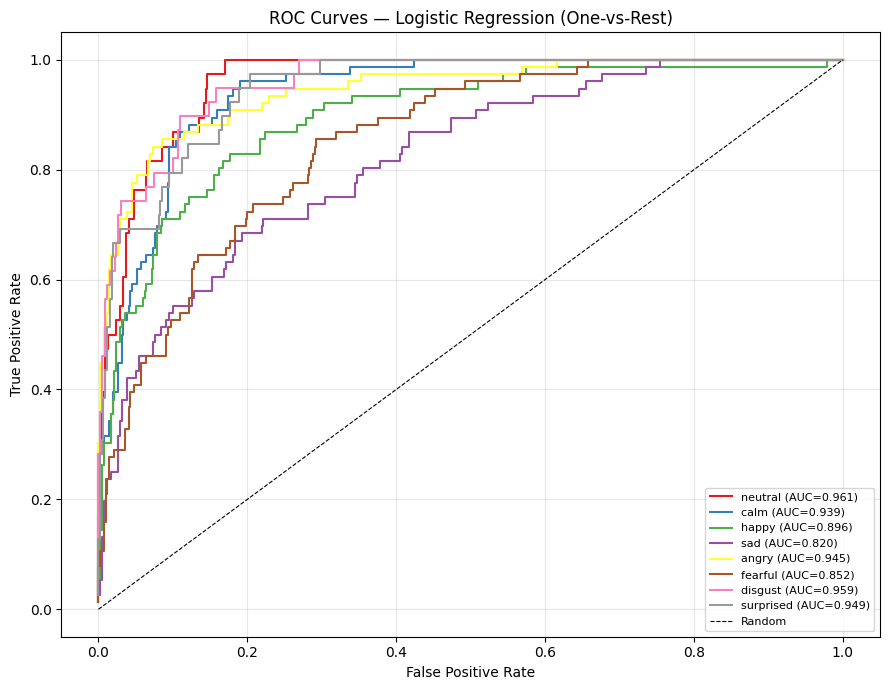

In [47]:
# ROC curves for logistic regression — one curve per emotion
# higher AUC = model can better distinguish that emotion from all others
proba      = lr.predict_proba(X_test_sc)
colors_roc = plt.cm.Set1(np.linspace(0, 1, 8))

fig, ax = plt.subplots(figsize=(9, 7))
for i, cls in enumerate(lr.classes_):
    y_bin  = (y_test == cls).astype(int)
    order  = np.argsort(proba[:, i])[::-1]
    y_s    = y_bin[order]
    tp     = np.cumsum(y_s)
    fp     = np.cumsum(1 - y_s)
    tpr    = tp / (tp.max() + 1e-10)
    fpr    = fp / (fp.max() + 1e-10)
    auc    = abs(np.trapezoid(tpr, fpr))
    ax.plot(fpr, tpr, color=colors_roc[i], linewidth=1.5,
            label=f'{EMOTION_NAMES[cls]} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Logistic Regression (One-vs-Rest)')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/week7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Results

In [48]:
summary_df = pd.DataFrame(summary)
summary_df['week'] = 7
summary_df.to_csv('../outputs/week7_results.csv', index=False)

print('Saved: week7_results.csv')
print('\nOutputs saved:')
for f in ['lr_loss_curve.png','lr_confusion_matrix.png',
          'lr_hyperparam_heatmap.png','gnb_confusion_matrix.png',
          'gnb_class_means.png','knn_tuning.png',
          'knn_confusion_matrix.png','week7_model_comparison.png',
          'week7_confusion_matrices.png','week7_roc_curves.png']:
    print(f'  ../outputs/{f}')

Saved: week7_results.csv

Outputs saved:
  ../outputs/lr_loss_curve.png
  ../outputs/lr_confusion_matrix.png
  ../outputs/lr_hyperparam_heatmap.png
  ../outputs/gnb_confusion_matrix.png
  ../outputs/gnb_class_means.png
  ../outputs/knn_tuning.png
  ../outputs/knn_confusion_matrix.png
  ../outputs/week7_model_comparison.png
  ../outputs/week7_confusion_matrices.png
  ../outputs/week7_roc_curves.png


In [49]:
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.naive_bayes import GaussianNB as SkGaussianNB
from sklearn.neighbors import KNeighborsClassifier as SkKNN

sk_models = {
    "sklearn Logistic Regression": SkLogisticRegression(max_iter=5000, random_state=42),
    "sklearn GaussianNB": SkGaussianNB(),
    "sklearn KNN k=3 manhattan": SkKNN(n_neighbors=3, metric="manhattan")
}

sk_results = []

for name, model in sk_models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)

    sk_results.append({
        "Model": name,
        "Accuracy": accuracy(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro")
    })

sk_results_df = pd.DataFrame(sk_results)
sk_results_df

,Model,Accuracy,Macro F1
0,sklearn Logistic Regression,0.622984,0.631835
1,sklearn GaussianNB,0.346774,0.334310
2,sklearn KNN k=3 manhattan,0.588710,0.575745


In [51]:
mini_results_df = pd.DataFrame([
    {"Model": "MiniLearn Logistic Regression", "Accuracy": 0.614919, "Macro F1": 0.623556},
    {"Model": "MiniLearn GaussianNB", "Accuracy": 0.346774, "Macro F1": 0.334310},
    {"Model": "MiniLearn KNN k=3 manhattan", "Accuracy": 0.618952, "Macro F1": 0.600936},
])

comparison_df = pd.concat([
    mini_results_df.assign(Source="MiniLearn"),
    sk_results_df.assign(Source="sklearn")
], ignore_index=True)

comparison_df[["Source", "Model", "Accuracy", "Macro F1"]]

,Source,Model,Accuracy,Macro F1
0,MiniLearn,MiniLearn Logistic Regression,0.614919,0.623556
1,MiniLearn,MiniLearn GaussianNB,0.346774,0.334310
2,MiniLearn,MiniLearn KNN k=3 manhattan,0.618952,0.600936
3,sklearn,sklearn Logistic Regression,0.622984,0.631835
4,sklearn,sklearn GaussianNB,0.346774,0.334310
5,sklearn,sklearn KNN k=3 manhattan,0.588710,0.575745


### MiniLearn vs scikit-learn comparison

The scikit-learn Logistic Regression model achieved the best Week 7 macro F1 score at 0.6318, slightly higher than the MiniLearn Logistic Regression score of 0.6236. This shows that the MiniLearn implementation is behaving correctly and closely matches the optimized library implementation.

Gaussian Naive Bayes produced the same result in MiniLearn and scikit-learn, confirming that the low score is mainly due to the model assumption rather than a coding error. The independence assumption is too strong for correlated audio features such as MFCCs and spectral features.

MiniLearn KNN slightly outperformed sklearn KNN with the tested settings. This may be due to small implementation differences, tie handling, or distance calculation details. Both results show that local neighborhood structure is useful but still not enough to fully separate similar emotions.

Overall, Week 7 confirms that Logistic Regression is the strongest simple classifier so far, while Naive Bayes struggles with correlated audio features.